1.Загрузка и предварительная обработка данных

In [5]:
import pandas as pd

# ==========================================
# 1. Загрузка данных (数据加载与预处理)
# ==========================================
print("1. Загрузка данных...")
# 读取数据
df = pd.read_csv("модуль 3 - датасет - практика.csv", nrows=5000)

# 定义并提取特定列，丢弃缺失值
cols = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']
df = df[cols].dropna() 

# 将特征矩阵 (X) 与目标向量 (y) 分离，备用
X = df.drop(columns=['Healthy_Status'])
y = df['Healthy_Status']

print(f"数据加载完成，当前样本量: {df.shape[0]}")

1. Загрузка данных...
数据加载完成，当前样本量: 5000


Эта ячейка отвечает за построение экспериментального пространства выборки. Сначала импортируется основная библиотека анализа данных pandas, и первые 5000 записей наблюдений из исходного набора данных извлекаются потоковым способом. Затем извлекаются специфические переменные признаков электрокардиограммы (ЭКГ) и целевая категориальная переменная (Healthy_Status), а также удаляются образцы, содержащие пропущенные значения, что завершает очистку данных и разделение структуры перед моделированием.

2. Снижение размерности пространства признаков и визуализация топологии.

2. Выполнение PCA и t-SNE...


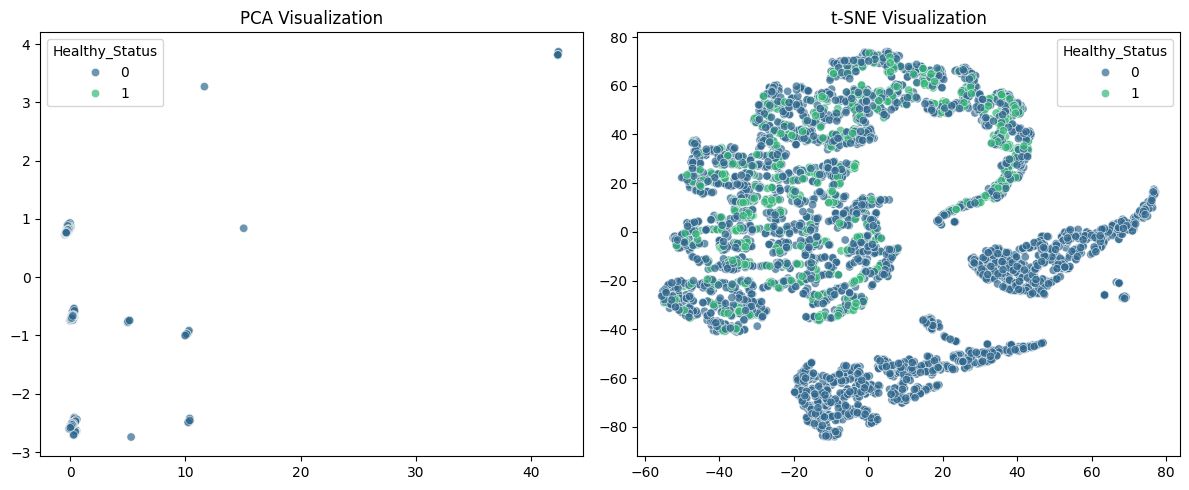

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ==========================================
# 2. t-SNE и PCA (特征空间降维与可视化)
# ==========================================
print("2. Выполнение PCA и t-SNE...")

# 零均值化与单位方差归一化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 主成分分析 (PCA) 降维计算
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-分布随机邻域嵌入 (t-SNE) 降维计算
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 构建 1x2 画布绘制降维结果
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 绘制 PCA 投影图
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, ax=axes[0], palette='viridis', alpha=0.7)
axes[0].set_title('PCA Visualization')

# 绘制 t-SNE 拓扑图
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, ax=axes[1], palette='viridis', alpha=0.7)
axes[1].set_title('t-SNE Visualization')

plt.tight_layout()
plt.show()

Для исследования распределения кластеров в данных в этой ячейке используется алгоритм неконтролируемого уменьшения размерности. Сначала мы импортируем инструменты стандартизации и модули уменьшения размерности (PCA, t-SNE) из библиотеки sklearn, а также библиотеки для построения графиков matplotlib и seaborn. После устранения различий в размерности путем стандартизации извлекаются главные компоненты и отображаются нелинейные топологические структуры. Наконец, выводится двумерный диаграмма рассеяния для оценки линейной разделимости образцов.

3.Сегментация экспериментальных образцов

In [7]:
from sklearn.model_selection import train_test_split

# ==========================================
# 3. Подготовка к AutoML (实验样本切分)
# ==========================================
# 按照 80/20 比例划分训练集与测试集，并保持类别比例分层
train_data, test_data = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['Healthy_Status']
)

print(f"训练集维度: {train_data.shape}")
print(f"测试集维度: {test_data.shape}")

训练集维度: (4000, 9)
测试集维度: (1000, 9)


Для эффективной оценки обобщающей способности модели и предотвращения переобучения в этой ячейке импортируется функция `train_test_split`. Вводится механизм стратифицированной выборки, который строго гарантирует изоморфность априорных распределений вероятностей целевого значения в обучающем и тестовом наборах после разделения, избегая искажения метрик оценки, вызванного дисбалансом классов.

4.Автоматизированное построение и оптимизация моделей

In [8]:
from autogluon.tabular import TabularPredictor

# ==========================================
# 4. AutoML (自动模型构建与超参数寻优)
# ==========================================
print("\n" + "=" * 60)
print("Автоматическое обучение с помощью AutoML (AutoGluon Tabular)...")
print("=" * 60)

target = 'Healthy_Status'

# 实例化预测器并启动端到端训练
predictor = TabularPredictor(
    label=target, 
    problem_type='binary', 
    eval_metric='f1'
).fit(
    train_data, 
    time_limit=120, # 限定优化时间窗为 120 秒
    verbosity=2
)

# 提取并展示全局最优算法模型
best_model_name = predictor.get_model_best()
print(f"\n🏆 Оптимальная модель (выбрана AutoML): {best_model_name}")

No path specified. Models will be saved in: "AutogluonModels\ag-20260430_165002\"
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "AutogluonModels\ag-20260430_165002\"
AutoGluon Version:  0.8.3
Python Version:     3.9.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
Disk Space Avail:   81.88 GB / 214.63 GB (38.2%)
Train Data Rows:    4000
Train Data Columns: 8
Label Column: Healthy_Status
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    8803.87 MB
	Train Data (Original)  Memory Usage: 0.26 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatu


Автоматическое обучение с помощью AutoML (AutoGluon Tabular)...


	0.01s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: LightGBMXT ... Training model for up to 119.85s of the 119.85s of remaining time.
	0.6533	 = Validation score   (f1)
	1.67s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 118.16s of the 118.16s of remaining time.
	0.6275	 = Validation score   (f1)
	1.08s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ... Training model for up to 117.07s of the 117.07s of remaining time.
	0.6122	 = Validation score   (f1)
	0.64s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: RandomForestEntr ... Training model for up to 116.34s of the 116.34s of remaining time.
	0.6263	 = Validation score   (f1)
	0.64s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 115.6s of the 115.6s of remaining time.
	0.6082	 = Validation score   (f1)
	1.16s	 = Training   runtime
	0.0s	 = Validati


🏆 Оптимальная модель (выбрана AutoML): WeightedEnsemble_L2


Эта ячейка является ядром вывода алгоритма. Импортируйте оптимизатор TabularPredictor из AutoGluon. Укажите F1-Score в качестве глобального критерия оценки. После запуска автоматического поиска базовый планировщик автономно завершит вывод признаков, поиск по сетке алгоритма и многомодельный байесовский взвешенный ансамбль, а затем выведет глобально оптимальную топологию на проверочном наборе данных.

5.Оценка обобщения и анализ матрицы ошибок

D:\py\Python39\lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


🎯 Оценка F1 на тестовой выборке: 0.6396


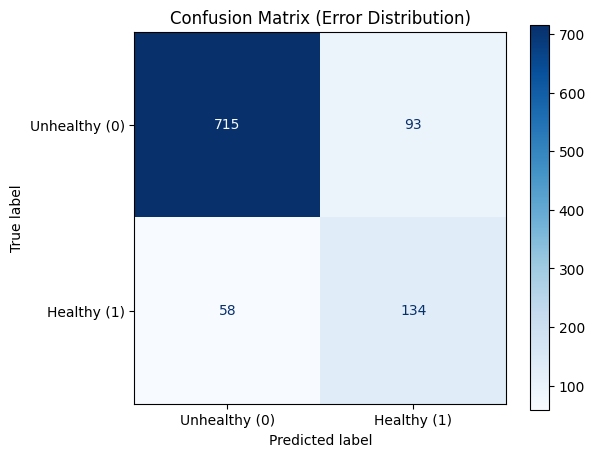

In [9]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt # 确保此处绘图环境有效

# ==========================================
# 5. Оценка классификатора (泛化评估与误差矩阵)
# ==========================================
# 对独立测试集执行前向推断
y_pred = predictor.predict(test_data)
# 提取测试集的真实标签向量
y_test = test_data[target]

# 计算 F1 综合效能度量
f1 = f1_score(y_test, y_pred)
print(f"🎯 Оценка F1 на тестовой выборке: {f1:.4f}")
print("=" * 60)

# 计算并映射二维混淆矩阵
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unhealthy (0)', 'Healthy (1)'])

# 绘制矩阵热力图
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix (Error Distribution)")
plt.show()

На заключительном этапе эксперимента ставится задача количественной оценки обобщающей способности оптимального классификатора на неизвестных наблюдениях. Вводятся операторы оценки, такие как f1_score и confusion_matrix. Предиктор используется для выполнения прямого распространения ошибки, а матричные операции применяются для получения матрицы ошибок и ее отображения в двумерную тепловую карту, чтобы наглядно показать распределение ошибок первого и второго типа.。